# Sensitivity and Robustness Analysis 

This notebook tests whether the conclusions of the executable gamma-scalping backtest remain robust once modelling and execution assumptions are varied.

This uses the validated executable backtest as a base-case scenario and systematically changes assumptions. The underlying option position, historical window, market data and P&L accounting remain consistent with the previous noteboooks.

Sensitivities considered are:
- The residual delta-hedging band.
- ES transacrtion costs and execution friction costs.
- Volatility input used to reprice the straddle daily.
- Fractional vs whole-contract hedge sizing.

The same core outputs are analysed for each sensitivity test as a robustness test.

In [68]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statistics import NormalDist

pd.set_option(
    "display.float_format",
    lambda x: f"{x:,.4f}",
)

plt.rcParams["figure.figsize"] = (10, 4)

## Base-case Configuration

Default parameters replicate the executable backtest before any robustness assumptions are changed.

In [69]:
# Contract specifications
SPX_OPTION_MULTIPLIER = 100.0
ES_POINT_VALUE = 50.0

# Strategy specification
N_STRADDLES = 1
DELTA_REHEDGE_BAND = 0.10

# Option assumptions
RISK_FREE_RATE = 0.0
OPTION_EXPIRY = pd.Timestamp("2020-03-20")
STRIKE_INTERVAL = 5.0

In [70]:
# ES execution-friction assumptions
ES_TICK_SIZE = 0.25

# Base-case executable assumption:
# half a tick for crossing the bid-ask spread plus
# half a tick of additional adverse slippage.
ES_HALF_SPREAD_TICKS = 0.5
ES_SLIPPAGE_TICKS = 0.5

ES_EXECUTION_FRICTION_POINTS = (
    ES_HALF_SPREAD_TICKS
    + ES_SLIPPAGE_TICKS
) * ES_TICK_SIZE

# All-in explicit institutional ES trading cost:
# exchange, clearing and brokerage, per contract per side.
ES_COMMISSION_PER_CONTRACT_SIDE = 1.25

# Market data
SPX_TICKER = "^GSPC"
VOL_TICKER = "^VIX9D"

# Contract-specific ES hedge data
ES_MARCH_CONTRACT = "ESH20"
ES_JUNE_CONTRACT = "ESM20"
ES_ROLL_DATE = pd.Timestamp("2020-03-12")
ES_DATA_FILE = "Data/es_futures_mar2020.csv"

# Backtest period
INTERVAL = "1d"
START = "2020-03-10"
END = "2020-03-21"  # yfinance end date is exclusive

## Reusable Backtest Engine

The executable backtest logic is retained so that each sensitivity changes only the assumption being tested. Default configurations reproduce the executable base case.

In [71]:
%%capture
%run OptionsVolatilityAnalysis_ExecutableBacktest.ipynb

# Preserve the validated executable result before the
# sensitivity notebook redefines run_backtest().
executable_res = res.copy()

In [72]:
def run_backtest(
    market,
    delta_rehedge_band=0.10,
    commission_per_contract_side=1.25,
    execution_friction_points=0.25,
    sizing_mode="integer",
):

    if sizing_mode not in {"integer", "fractional"}:
        raise ValueError(
            "sizing_mode must be 'integer' or 'fractional'."
        )

    def hedge_target(option_delta):
        continuous_target = continuous_es_target(
            option_delta
        )

        if sizing_mode == "fractional":
            return continuous_target

        return integer_es_target(
            option_delta
        )

    def scenario_commission(trade_qty):
        return (
            abs(trade_qty)
            * commission_per_contract_side
        )

    def scenario_execution_cost(trade_qty):
        return (
            abs(trade_qty)
            * ES_POINT_VALUE
            * execution_friction_points
        )

    records = []

    first_date = market.index[0]
    first_row = market.iloc[0]

    first_metrics = straddle_metrics(
        S=first_row["SPX"],
        K=first_row["K"],
        sigma=first_row["iv_proxy"],
        T=first_row["T"],
        n=N_STRADDLES,
    )

    continuous_target = continuous_es_target(
        first_metrics["delta"]
    )

    executable_target = hedge_target(
        first_metrics["delta"]
    )

    q_fut = executable_target

    entry_commission = scenario_commission(
        q_fut
    )

    entry_execution_cost = scenario_execution_cost(
        q_fut
    )

    net_delta_after = (
        first_metrics["delta"]
        + q_fut
        * ES_POINT_VALUE
        / SPX_OPTION_MULTIPLIER
    )

    records.append(
        {
            "Date": first_date,
            "SPX": first_row["SPX"],
            "VIX9D": first_row["VIX9D"],
            "iv_proxy_used": first_row["iv_proxy"],
            "straddle_price": first_metrics["straddle_price"],
            "delta": first_metrics["delta"],
            "gamma": first_metrics["gamma"],
            "theta": first_metrics["theta"],
            "ES_contract": first_row["ES_contract"],
            "ES_settlement_change": np.nan,
            "continuous_es_target": continuous_target,
            "integer_es_target": integer_es_target(
                first_metrics["delta"]
            ),
            "net_delta_before": first_metrics["delta"],
            "net_delta_after": net_delta_after,
            "q_fut_start": 0.0,
            "q_fut_end": q_fut,
            "contracts_traded": abs(q_fut),
            "option_pnl": 0.0,
            "hedge_pnl": 0.0,
            "commission": entry_commission,
            "execution_cost": entry_execution_cost,
            "total_pnl": (
                -entry_commission
                -entry_execution_cost
            ),
            "delta_attribution": 0.0,
            "gamma_attribution": 0.0,
            "theta_attribution": 0.0,
            "option_residual": 0.0,
            "event": "OPEN",
        }
    )

    prev_date = first_date
    prev_row = first_row
    prev_metrics = first_metrics
    prev_contract = first_row["ES_contract"]

    for ts, row in market.iloc[1:].iterrows():

        metrics = straddle_metrics(
            S=row["SPX"],
            K=row["K"],
            sigma=row["iv_proxy"],
            T=row["T"],
            n=N_STRADDLES,
        )

        option_pnl = (
            metrics["straddle_price"]
            - prev_metrics["straddle_price"]
        ) * SPX_OPTION_MULTIPLIER

        if pd.isna(row["ES_settlement_change"]):
            raise RuntimeError(
                f"Missing ES settlement change for {ts.date()}."
            )

        q_fut_start = q_fut

        hedge_pnl = (
            q_fut_start
            * ES_POINT_VALUE
            * row["ES_settlement_change"]
        )

        dS = row["SPX"] - prev_row["SPX"]
        dt_year = (ts - prev_date).days / 365.0

        delta_attribution = (
            prev_metrics["delta"]
            * SPX_OPTION_MULTIPLIER
            * dS
        )

        gamma_attribution = (
            0.5
            * prev_metrics["gamma"]
            * SPX_OPTION_MULTIPLIER
            * dS**2
        )

        theta_attribution = (
            prev_metrics["theta"]
            * SPX_OPTION_MULTIPLIER
            * dt_year
        )

        option_residual = (
            option_pnl
            - delta_attribution
            - gamma_attribution
            - theta_attribution
        )

        net_delta_before = (
            metrics["delta"]
            + q_fut_start
            * ES_POINT_VALUE
            / SPX_OPTION_MULTIPLIER
        )

        continuous_target = continuous_es_target(
            metrics["delta"]
        )

        integer_target = integer_es_target(
            metrics["delta"]
        )

        executable_target = hedge_target(
            metrics["delta"]
        )

        q_target = q_fut_start
        contracts_traded = 0.0
        commission = 0.0
        execution_cost = 0.0
        event = "HOLD"

        contract_changed = (
            row["ES_contract"] != prev_contract
        )

        is_expiry = (
            ts.normalize()
            == OPTION_EXPIRY.normalize()
        )

        
        if is_expiry:
            continuous_target = 0.0
            integer_target = 0
            executable_target = 0.0

            q_target = 0.0

            trade_qty = -q_fut_start

            contracts_traded = abs(
                trade_qty
            )

            commission = scenario_commission(
                trade_qty
            )

            execution_cost = scenario_execution_cost(
                trade_qty
            )

            event = "EXPIRY_CLOSE"

        elif contract_changed:
            q_target = executable_target

            # A roll consists of two distinct transactions:
            # 1. close the old futures contract;
            # 2. establish the hedge in the new futures contract.
            close_old_qty = -q_fut_start
            open_new_qty = q_target

            contracts_traded = (
                abs(close_old_qty)
                + abs(open_new_qty)
            )

            commission = (
                scenario_commission(close_old_qty)
                + scenario_commission(open_new_qty)
            )

            execution_cost = (
                scenario_execution_cost(close_old_qty)
                + scenario_execution_cost(open_new_qty)
            )

            event = "ROLL"

        elif abs(net_delta_before) > delta_rehedge_band:
            q_target = executable_target

            trade_qty = (
                q_target - q_fut_start
            )

            if not np.isclose(
                trade_qty,
                0.0,
                atol=1e-12,
            ):
                contracts_traded = abs(
                    trade_qty
                )

                commission = scenario_commission(
                    trade_qty
                )

                execution_cost = scenario_execution_cost(
                    trade_qty
                )

                event = "REHEDGE"

            elif sizing_mode == "integer":
                event = "GRANULARITY_HOLD"

        net_delta_after = (
            0.0
            if is_expiry
            else (
                metrics["delta"]
                + q_target
                * ES_POINT_VALUE
                / SPX_OPTION_MULTIPLIER
            )
        )

        total_pnl = (
            option_pnl
            + hedge_pnl
            - commission
            - execution_cost
        )

        records.append(
            {
                "Date": ts,
                "SPX": row["SPX"],
                "VIX9D": row["VIX9D"],
                "iv_proxy_used": row["iv_proxy"],
                "straddle_price": metrics["straddle_price"],
                "delta": metrics["delta"],
                "gamma": metrics["gamma"],
                "theta": metrics["theta"],
                "ES_contract": row["ES_contract"],
                "ES_settlement_change": row["ES_settlement_change"],
                "continuous_es_target": continuous_target,
                "integer_es_target": integer_target,
                "net_delta_before": net_delta_before,
                "net_delta_after": net_delta_after,
                "q_fut_start": q_fut_start,
                "q_fut_end": q_target,
                "contracts_traded": contracts_traded,
                "option_pnl": option_pnl,
                "hedge_pnl": hedge_pnl,
                "commission": commission,
                "execution_cost": execution_cost,
                "total_pnl": total_pnl,
                "delta_attribution": delta_attribution,
                "gamma_attribution": gamma_attribution,
                "theta_attribution": theta_attribution,
                "option_residual": option_residual,
                "event": event,
            }
        )

        q_fut = q_target

        prev_date = ts
        prev_row = row
        prev_metrics = metrics
        prev_contract = row["ES_contract"]

    return records

## Base-Case Reproduction

Before running any sensitivities, the results are checked against the frozen executable benchmark. This ensures that the framework has not changed the base-case result.

In [73]:
def summarise_backtest(records):

    res = (
        pd.DataFrame(records)
        .set_index("Date")
        .sort_index()
    )

    summary = {
        "Total P&L": res["total_pnl"].sum(),
        "Option P&L": res["option_pnl"].sum(),
        "ES hedge P&L": res["hedge_pnl"].sum(),
        "Transaction costs": (
            res["commission"].sum()
            + res["execution_cost"].sum()
        ),
        "ES turnover": res["contracts_traded"].sum(),
        "Rehedges": int(
            (res["event"] == "REHEDGE").sum()
        ),
        "Granularity holds": int(
            (res["event"] == "GRANULARITY_HOLD").sum()
        ),
        "Mean abs residual delta": (
            res["net_delta_after"].abs().mean()
        ),
        "Max abs residual delta": (
            res["net_delta_after"].abs().max()
        ),
    }

    return res, summary

In [74]:
def validate_backtest(
    res,
    market_input,
    delta_band,
    commission_per_contract_side,
    execution_friction_points,
    sizing_mode,
):
    """
    Validate accounting and execution invariants for a sensitivity run.
    """

    # Backtest observations must align with the supplied market data.
    if not res.index.equals(market_input.index):
        raise RuntimeError(
            "Backtest dates do not align with market input."
        )

    # Option Greek attribution must reconcile to option P&L.
    option_attribution_sum = (
        res["delta_attribution"]
        + res["gamma_attribution"]
        + res["theta_attribution"]
        + res["option_residual"]
    )

    if not np.allclose(
        option_attribution_sum,
        res["option_pnl"],
        atol=1e-8,
        rtol=1e-10,
    ):
        raise RuntimeError(
            "Option P&L attribution does not reconcile."
        )

    # Integer scenarios must contain only executable whole ES quantities.
    if sizing_mode == "integer":

        for column in [
            "q_fut_start",
            "q_fut_end",
            "contracts_traded",
        ]:
            if not np.allclose(
                res[column],
                np.round(res[column]),
                atol=1e-12,
            ):
                raise RuntimeError(
                    f"Non-integer ES quantity detected in {column}."
                )

    # Transaction costs must never be negative.
    if (res["commission"] < 0).any():
        raise RuntimeError(
            "Negative futures commission detected."
        )

    if (res["execution_cost"] < 0).any():
        raise RuntimeError(
            "Negative ES execution cost detected."
        )

    # Commission must reconcile exactly to scenario turnover.
    expected_commission = (
        res["contracts_traded"]
        * commission_per_contract_side
    )

    if not np.allclose(
        res["commission"],
        expected_commission,
        atol=1e-12,
    ):
        raise RuntimeError(
            "Futures commissions do not reconcile "
            "to scenario turnover."
        )

    # Spread/slippage must reconcile exactly to scenario turnover.
    expected_execution_cost = (
        res["contracts_traded"]
        * ES_POINT_VALUE
        * execution_friction_points
    )

    if not np.allclose(
        res["execution_cost"],
        expected_execution_cost,
        atol=1e-12,
    ):
        raise RuntimeError(
            "ES execution costs do not reconcile "
            "to scenario turnover."
        )

    # No trade means no transaction cost.
    no_trade_mask = (
        res["contracts_traded"] == 0
    )

    if not np.allclose(
        res.loc[no_trade_mask, "commission"],
        0.0,
        atol=1e-12,
    ):
        raise RuntimeError(
            "Commission charged without a futures transaction."
        )

    if not np.allclose(
        res.loc[no_trade_mask, "execution_cost"],
        0.0,
        atol=1e-12,
    ):
        raise RuntimeError(
            "Execution cost charged without a futures transaction."
        )

    # GRANULARITY_HOLD is only meaningful under integer sizing.
    granularity_hold_mask = (
        res["event"] == "GRANULARITY_HOLD"
    )

    if (
        sizing_mode != "integer"
        and granularity_hold_mask.any()
    ):
        raise RuntimeError(
            "GRANULARITY_HOLD detected under fractional sizing."
        )

    if granularity_hold_mask.any():

        if not (
            res.loc[
                granularity_hold_mask,
                "net_delta_before",
            ].abs()
            > delta_band
        ).all():
            raise RuntimeError(
                "GRANULARITY_HOLD recorded without "
                "a delta-band breach."
            )

        if not np.allclose(
            res.loc[
                granularity_hold_mask,
                "integer_es_target",
            ],
            res.loc[
                granularity_hold_mask,
                "q_fut_start",
            ],
            atol=1e-12,
        ):
            raise RuntimeError(
                "GRANULARITY_HOLD recorded when the "
                "integer target differs from the held position."
            )

        if not np.allclose(
            res.loc[
                granularity_hold_mask,
                "contracts_traded",
            ],
            0.0,
            atol=1e-12,
        ):
            raise RuntimeError(
                "Turnover recorded on GRANULARITY_HOLD."
            )

    # Today's starting hedge must equal yesterday's ending hedge.
    if not np.allclose(
        res["q_fut_start"].iloc[1:],
        res["q_fut_end"].shift(1).iloc[1:],
        atol=1e-12,
    ):
        raise RuntimeError(
            "ES hedge carry-forward is inconsistent."
        )

    # Futures P&L must be earned by the position held at
    # the start of the interval.
    expected_hedge_pnl = (
        res["q_fut_start"]
        * ES_POINT_VALUE
        * res["ES_settlement_change"]
    )

    hedge_pnl_mask = (
        res["ES_settlement_change"].notna()
    )

    if not np.allclose(
        res.loc[
            hedge_pnl_mask,
            "hedge_pnl",
        ],
        expected_hedge_pnl.loc[
            hedge_pnl_mask
        ],
        atol=1e-12,
    ):
        raise RuntimeError(
            "Hedge P&L does not reconcile to the "
            "start-of-interval ES position."
        )

    # A roll-type event must occur exactly when the
    # active futures contract changes.
    contract_change_mask = (
        res["ES_contract"]
        != res["ES_contract"].shift(1)
    )

    contract_change_mask.iloc[0] = False

    roll_event_mask = (
        res["event"] == "ROLL"
    )

    if not np.array_equal(
        roll_event_mask.to_numpy(),
        contract_change_mask.to_numpy(),
    ):
        raise RuntimeError(
            "Roll events do not reconcile to ES contract changes."
        )

    hedge_decision_mask = res["event"].isin(
        ["REHEDGE", "GRANULARITY_HOLD"]
    )

    # Any actual hedge decision must correspond to
    # a residual-delta band breach.
    if hedge_decision_mask.any():

        if not (
            res.loc[
                hedge_decision_mask,
                "net_delta_before",
            ].abs()
            > delta_band
        ).all():
            raise RuntimeError(
                "Hedge decision recorded without "
                "a delta-band breach."
            )

    # Exactly one explicit expiry close is required.
    expiry_mask = (
        res["event"] == "EXPIRY_CLOSE"
    )

    if expiry_mask.sum() != 1:
        raise RuntimeError(
            "Expected exactly one EXPIRY_CLOSE."
        )

    expiry_row = (
        res.loc[expiry_mask].iloc[0]
    )

    expected_expiry_turnover = abs(
        expiry_row["q_fut_start"]
    )

    if not np.isclose(
        expiry_row["contracts_traded"],
        expected_expiry_turnover,
        atol=1e-12,
    ):
        raise RuntimeError(
            "Expiry-close turnover does not reconcile."
        )

    # Strategy P&L identity must hold for every observation.
    expected_total_pnl = (
        res["option_pnl"]
        + res["hedge_pnl"]
        - res["commission"]
        - res["execution_cost"]
    )

    if not np.allclose(
        res["total_pnl"],
        expected_total_pnl,
        atol=1e-12,
    ):
        raise RuntimeError(
            "Strategy P&L accounting identity failed."
        )

    # Backtest must terminate at option expiry.
    if (
        res.index[-1].normalize()
        != OPTION_EXPIRY.normalize()
    ):
        raise RuntimeError(
            "Backtest does not terminate on option expiry."
        )

    # No ES hedge may remain after expiry.
    if not np.isclose(
        res["q_fut_end"].iloc[-1],
        0.0,
        atol=1e-12,
    ):
        raise RuntimeError(
            "Backtest ended with an open ES hedge."
        )

    if (
        res["event"].iloc[-1]
        != "EXPIRY_CLOSE"
    ):
        raise RuntimeError(
            "Final event is not EXPIRY_CLOSE."
        )

In [75]:
base_records = run_backtest(
    market=market,
    delta_rehedge_band=DELTA_REHEDGE_BAND,
    commission_per_contract_side=(
        ES_COMMISSION_PER_CONTRACT_SIDE
    ),
    execution_friction_points=(
        ES_EXECUTION_FRICTION_POINTS
    ),
    sizing_mode="integer",
)

base_res, base_summary = summarise_backtest(
    base_records
)

# Apply the sensitivity-engine validation controls.
validate_backtest(
    res=base_res,
    market_input=market,
    delta_band=DELTA_REHEDGE_BAND,
    commission_per_contract_side=(
        ES_COMMISSION_PER_CONTRACT_SIDE
    ),
    execution_friction_points=(
        ES_EXECUTION_FRICTION_POINTS
    ),
    sizing_mode="integer",
)

# Preserve the existing final-P&L regression check.
BASE_CASE_PNL = 7821.118624

if not np.isclose(
    base_summary["Total P&L"],
    BASE_CASE_PNL,
    atol=1e-6,
):
    raise RuntimeError(
        "Sensitivity engine does not reproduce "
        "the executable base-case P&L."
    )

# Stronger check: the sensitivity engine must reproduce
# the executable engine's core path row by row.
comparison_columns = [
    "continuous_es_target",
    "integer_es_target",
    "net_delta_before",
    "net_delta_after",
    "q_fut_start",
    "q_fut_end",
    "contracts_traded",
    "option_pnl",
    "hedge_pnl",
    "commission",
    "execution_cost",
    "total_pnl",
    "event",
]

try:
    pd.testing.assert_frame_equal(
        base_res[comparison_columns],
        executable_res[comparison_columns],
        check_dtype=False,
        check_exact=False,
        rtol=1e-10,
        atol=1e-10,
    )
except AssertionError as exc:
    raise RuntimeError(
        "Sensitivity engine does not reproduce "
        "the executable base-case path."
    ) from exc

display(
    pd.Series(
        base_summary,
        name="Base Case",
    ).to_frame()
)

,Base Case
Total P&L,"7,821.1186"
Option P&L,"35,678.6186"
ES hedge P&L,"-27,775.0000"
Transaction costs,82.5000
ES turnover,6.0000
Rehedges,2.0000
Granularity holds,1.0000
Mean abs residual delta,0.0747
Max abs residual delta,0.1840


## Sensitivity Tests

Each test varies one assumption compared to the executable base case.

In [76]:
def run_scenario(
    market_input=None,
    delta_band=DELTA_REHEDGE_BAND,
    cost_multiplier=1.0,
    sizing_mode="integer",
):

    if market_input is None:
        market_input = market

    scenario_commission_rate = (
        ES_COMMISSION_PER_CONTRACT_SIDE
        * cost_multiplier
    )

    scenario_execution_friction = (
        ES_EXECUTION_FRICTION_POINTS
        * cost_multiplier
    )

    records = run_backtest(
        market=market_input,
        delta_rehedge_band=delta_band,
        commission_per_contract_side=(
            scenario_commission_rate
        ),
        execution_friction_points=(
            scenario_execution_friction
        ),
        sizing_mode=sizing_mode,
    )

    res, summary = summarise_backtest(
        records
    )

    validate_backtest(
        res=res,
        market_input=market_input,
        delta_band=delta_band,
        commission_per_contract_side=(
            scenario_commission_rate
        ),
        execution_friction_points=(
            scenario_execution_friction
        ),
        sizing_mode=sizing_mode,
    )

    return summary

### Delta-Rehedging Band

The residual delta threshold is varied while all other executable assumptions remain at their base-case values.

In [77]:
delta_bands = [
    0.00,
    0.10,
    0.25,
    0.30,
    0.35,
    0.40,
    0.50,
]

delta_results = []

for band in delta_bands:

    summary = run_scenario(
        delta_band=band
    )

    delta_results.append(
        {
            "Delta band": band,
            **summary,
        }
    )

delta_results = pd.DataFrame(
    delta_results
).set_index("Delta band")

display(delta_results)

,Total P&L,Option P&L,ES hedge P&L,Transaction costs,ES turnover,Rehedges,Granularity holds,Mean abs residual delta,Max abs residual delta
Delta band,,,,,,,,,
0.0000,"7,821.1186","35,678.6186","-27,775.0000",82.5000,6.0000,2,4,0.0747,0.1840
0.1000,"7,821.1186","35,678.6186","-27,775.0000",82.5000,6.0000,2,1,0.0747,0.1840
0.2500,"7,821.1186","35,678.6186","-27,775.0000",82.5000,6.0000,2,0,0.0747,0.1840
0.3000,"7,821.1186","35,678.6186","-27,775.0000",82.5000,6.0000,2,0,0.0747,0.1840
0.3500,"21,411.1186","35,678.6186","-14,212.5000",55.0000,4.0000,1,0,0.0894,0.3160
0.4000,"21,598.6186","35,678.6186","-14,025.0000",55.0000,4.0000,1,0,0.1478,0.3967
0.5000,"27,276.1186","35,678.6186","-8,375.0000",27.5000,2.0000,0,0,0.2562,0.4998


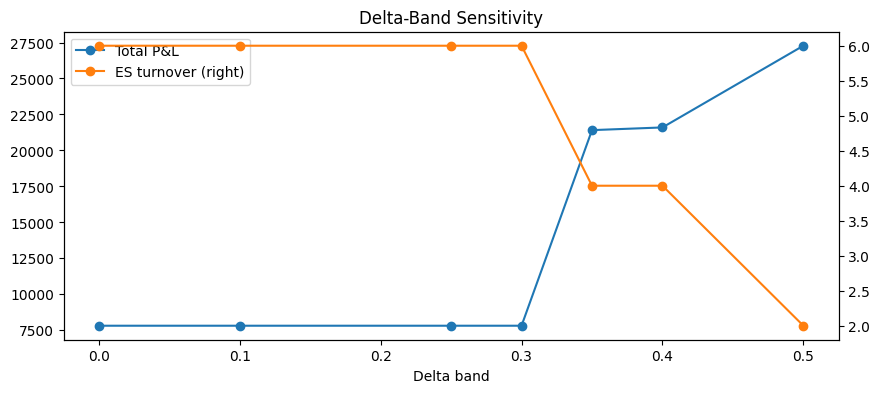

In [78]:
delta_results[
    [
        "Total P&L",
        "ES turnover",
    ]
].plot(
    marker="o",
    secondary_y="ES turnover",
)

plt.title(
    "Delta-Band Sensitivity"
)
plt.xlabel(
    "Residual Delta Band"
)
plt.show()

### Transaction-Cost Sensitivity

Commissions and ES spread/slippage costs are scaled together compared to the executable base case.

In [79]:
cost_multipliers = [
    0.0,
    0.5,
    1.0,
    2.0,
    4.0,
]

cost_results = []

for multiplier in cost_multipliers:

    summary = run_scenario(
        cost_multiplier=multiplier
    )

    cost_results.append(
        {
            "Cost multiplier": multiplier,
            **summary,
        }
    )

cost_results = pd.DataFrame(
    cost_results
).set_index("Cost multiplier")

display(cost_results)

,Total P&L,Option P&L,ES hedge P&L,Transaction costs,ES turnover,Rehedges,Granularity holds,Mean abs residual delta,Max abs residual delta
Cost multiplier,,,,,,,,,
0.0000,"7,903.6186","35,678.6186","-27,775.0000",0.0000,6.0000,2,1,0.0747,0.1840
0.5000,"7,862.3686","35,678.6186","-27,775.0000",41.2500,6.0000,2,1,0.0747,0.1840
1.0000,"7,821.1186","35,678.6186","-27,775.0000",82.5000,6.0000,2,1,0.0747,0.1840
2.0000,"7,738.6186","35,678.6186","-27,775.0000",165.0000,6.0000,2,1,0.0747,0.1840
4.0000,"7,573.6186","35,678.6186","-27,775.0000",330.0000,6.0000,2,1,0.0747,0.1840


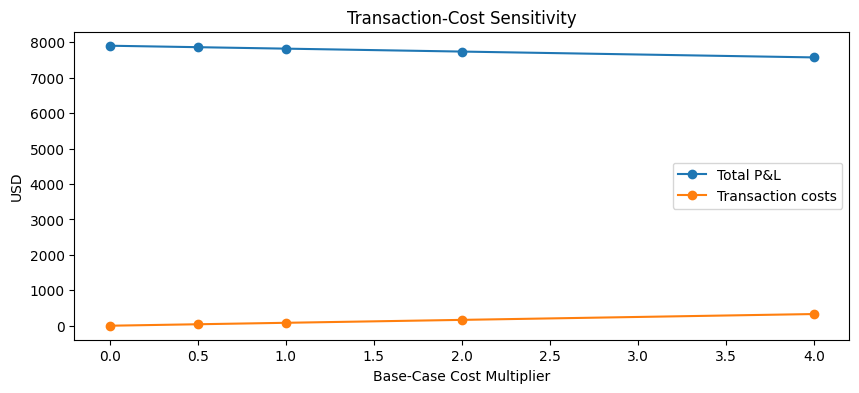

In [80]:
cost_results[
    [
        "Total P&L",
        "Transaction costs",
    ]
].plot(
    marker="o"
)

plt.title(
    "Transaction-Cost Sensitivity"
)
plt.xlabel(
    "Base-Case Cost Multiplier"
)
plt.ylabel(
    "USD"
)
plt.show()

### Volatility-Input Sensitivity

The VIX9D volatility proxy is shifted by fixed amounts. Underlying SPX and ES observations remain the same as in the executable base-case.

In [81]:
vol_shift_points = [
    -10,
    -5,
    0,
    5,
    10,
]

vol_results = []

for shift_points in vol_shift_points:

    scenario_market = market.copy()

    shift_decimal = (
        shift_points / 100.0
    )

    scenario_market["iv_proxy"] = (
        market["iv_proxy"]
        + shift_decimal
    )

    if (
        scenario_market["iv_proxy"] <= 0
    ).any():
        raise RuntimeError(
            "Volatility sensitivity produced "
            "a non-positive volatility input."
        )

    summary = run_scenario(
        market_input=scenario_market
    )

    vol_results.append(
        {
            "IV shift (vol pts)": shift_points,
            **summary,
        }
    )

vol_results = pd.DataFrame(
    vol_results
).set_index(
    "IV shift (vol pts)"
)

display(vol_results)

,Total P&L,Option P&L,ES hedge P&L,Transaction costs,ES turnover,Rehedges,Granularity holds,Mean abs residual delta,Max abs residual delta
IV shift (vol pts),,,,,,,,,
-10,"11,622.3759","39,479.8759","-27,775.0000",82.5000,6.0000,2,0,0.0580,0.1868
-5,"9,721.5841","37,579.0841","-27,775.0000",82.5000,6.0000,2,1,0.0656,0.1579
0,"7,821.1186","35,678.6186","-27,775.0000",82.5000,6.0000,2,1,0.0747,0.1840
5,"5,921.0156","33,778.5156","-27,775.0000",82.5000,6.0000,2,1,0.0834,0.2102
10,"4,021.3099","31,878.8099","-27,775.0000",82.5000,6.0000,2,2,0.0919,0.2337


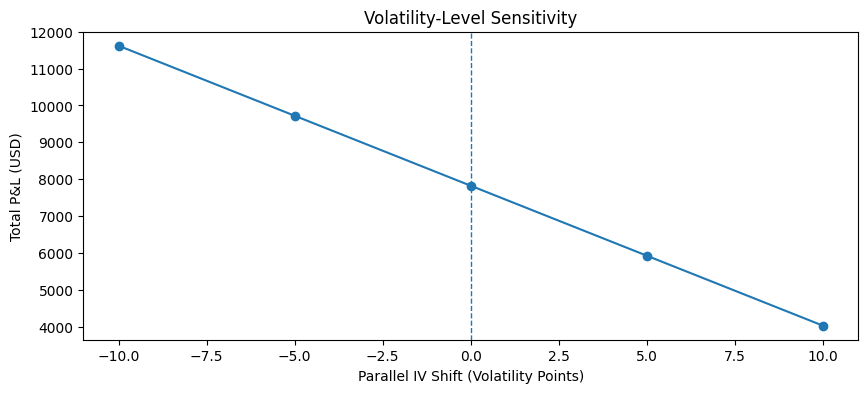

In [82]:
vol_results["Total P&L"].plot(
    marker="o"
)

plt.axvline(
    0.0,
    linestyle="--",
    linewidth=1,
)

plt.title(
    "Volatility-Level Sensitivity"
)
plt.xlabel(
    "Parallel IV Shift (Volatility Points)"
)
plt.ylabel(
    "Total P&L (USD)"
)
plt.show()

### Dynamic vs Frozen IV 

The executable model reprices the option using the daily VIX9D value. The frozen volatility case holds the VIX9D value at trade start date constant until option expiry.

In [83]:
frozen_vol_market = market.copy()

frozen_vol_market["iv_proxy"] = (
    market["iv_proxy"].iloc[0]
)

vol_method_results = pd.DataFrame(
    [
        {
            "Volatility input": "Dynamic VIX9D",
            **run_scenario(
                market_input=market
            ),
        },
        {
            "Volatility input": "Frozen at inception",
            **run_scenario(
                market_input=frozen_vol_market
            ),
        },
    ]
).set_index(
    "Volatility input"
)

display(vol_method_results)

,Total P&L,Option P&L,ES hedge P&L,Transaction costs,ES turnover,Rehedges,Granularity holds,Mean abs residual delta,Max abs residual delta
Volatility input,,,,,,,,,
Dynamic VIX9D,"7,821.1186","35,678.6186","-27,775.0000",82.5000,6.0000,2,1,0.0747,0.1840
Frozen at inception,"19,193.6186","35,678.6186","-16,375.0000",110.0000,8.0000,3,0,0.0323,0.1154


### Hedge Granularity

The executable whole-contract hedge is compared with a fractional-contract benchmark using the same pricing, timing and transaction-cost framework.

In [84]:
granularity_results = pd.DataFrame(
    [
        {
            "Hedge sizing": "Integer",
            **run_scenario(
                sizing_mode="integer"
            ),
        },
        {
            "Hedge sizing": "Fractional",
            **run_scenario(
                sizing_mode="fractional"
            ),
        },
    ]
).set_index(
    "Hedge sizing"
)

display(granularity_results)

,Total P&L,Option P&L,ES hedge P&L,Transaction costs,ES turnover,Rehedges,Granularity holds,Mean abs residual delta,Max abs residual delta
Hedge sizing,,,,,,,,,
Integer,"7,821.1186","35,678.6186","-27,775.0000",82.5000,6.0000,2,1,0.0747,0.1840
Fractional,"18,297.4763","35,678.6186","-17,295.6342",85.5081,6.2188,4,0,0.0135,0.0912


## Joint Band and Transaction-Cost Robustness

This captures the interaction of the delta-rehedging band with the transaction-cost multiplier. This test is used to determine whether P&L conclusions under different hedge toleracnes remain robust under different transaction-cost assumptions.

In [85]:
joint_results = []

for band in delta_bands:

    for multiplier in cost_multipliers:

        summary = run_scenario(
            delta_band=band,
            cost_multiplier=multiplier,
        )

        joint_results.append(
            {
                "Delta band": band,
                "Cost multiplier": multiplier,
                "Total P&L": summary[
                    "Total P&L"
                ],
                "ES turnover": summary[
                    "ES turnover"
                ],
            }
        )

joint_results = pd.DataFrame(
    joint_results
)

pnl_grid = joint_results.pivot(
    index="Delta band",
    columns="Cost multiplier",
    values="Total P&L",
)

display(pnl_grid)

Cost multiplier,0.0000,0.5000,1.0000,2.0000,4.0000
Delta band,,,,,
0.0000,"7,903.6186","7,862.3686","7,821.1186","7,738.6186","7,573.6186"
0.1000,"7,903.6186","7,862.3686","7,821.1186","7,738.6186","7,573.6186"
0.2500,"7,903.6186","7,862.3686","7,821.1186","7,738.6186","7,573.6186"
0.3000,"7,903.6186","7,862.3686","7,821.1186","7,738.6186","7,573.6186"
0.3500,"21,466.1186","21,438.6186","21,411.1186","21,356.1186","21,246.1186"
0.4000,"21,653.6186","21,626.1186","21,598.6186","21,543.6186","21,433.6186"
0.5000,"27,303.6186","27,289.8686","27,276.1186","27,248.6186","27,193.6186"


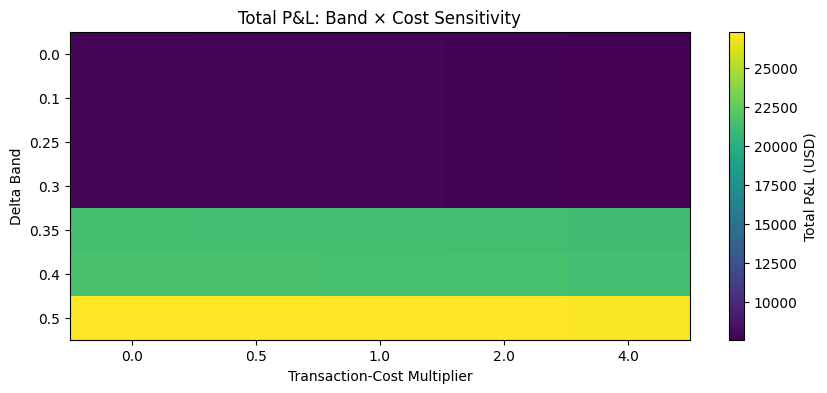

In [86]:
fig, ax = plt.subplots()

image = ax.imshow(
    pnl_grid.values,
    aspect="auto",
)

ax.set_xticks(
    range(len(pnl_grid.columns)),
    labels=pnl_grid.columns,
)

ax.set_yticks(
    range(len(pnl_grid.index)),
    labels=pnl_grid.index,
)

ax.set_xlabel(
    "Transaction-Cost Multiplier"
)
ax.set_ylabel(
    "Delta Band"
)
ax.set_title(
    "Total P&L: Band × Cost Sensitivity"
)

fig.colorbar(
    image,
    ax=ax,
    label="Total P&L (USD)",
)

plt.show()

## Robustness Summary

The tables below display the sensitivity results compared to the executable base case scenario. The purpose of this is to identify if the strategy conclusion is dependent on the initial modelling assumptions made to construct the strategy.

In [87]:
summary_metrics = [
    "Total P&L",
    "ES turnover",
    "Transaction costs",
    "Mean abs residual delta",
]

summary_sources = {
    "Base case": pd.Series(
        base_summary
    ),
    "Delta band 0.35": (
        delta_results.loc[0.35]
    ),
    "Delta band 0.50": (
        delta_results.loc[0.50]
    ),
    "4x transaction costs": (
        cost_results.loc[4.0]
    ),
    "IV -10 vol pts": (
        vol_results.loc[-10]
    ),
    "IV +10 vol pts": (
        vol_results.loc[10]
    ),
    "Frozen inception IV": (
        vol_method_results.loc[
            "Frozen at inception"
        ]
    ),
    "Fractional sizing": (
        granularity_results.loc[
            "Fractional"
        ]
    ),
}

robustness_summary = pd.DataFrame(
    {
        scenario: values[
            summary_metrics
        ]
        for scenario, values
        in summary_sources.items()
    }
).T

display(robustness_summary)

,Total P&L,ES turnover,Transaction costs,Mean abs residual delta
Base case,"7,821.1186",6.0000,82.5000,0.0747
Delta band 0.35,"21,411.1186",4.0000,55.0000,0.0894
Delta band 0.50,"27,276.1186",2.0000,27.5000,0.2562
4x transaction costs,"7,573.6186",6.0000,330.0000,0.0747
IV -10 vol pts,"11,622.3759",6.0000,82.5000,0.0580
IV +10 vol pts,"4,021.3099",6.0000,82.5000,0.0919
Frozen inception IV,"19,193.6186",8.0000,110.0000,0.0323
Fractional sizing,"18,297.4763",6.2188,85.5081,0.0135


## Interpretation and Limitations

These sensitivity results should be interpreted as robustness checks over the same short March 2020 historical window. Differences across scenarios show how strongly the result in the executable backtest notebook depends on hedge tolerance, trading costs, volatility inputs and hedge granularity.

Analysis retains daily data, SPX option-pricing framework, ES settlement data and roll convention of the executable backtest. Therefore, this does not change any of the core modelling data inputs - as these would move away from sensitivity/robustness testing and towards the creation of a different model.